# Meteorological covariates — exploratory data analysis

Southend Pier is the primary gauge for the ML-vs-UTide water level model. Before
adding pressure, wind, rainfall and discharge as model covariates, this notebook
checks the four cleaned meteorological files in `3_Cleaned/meteo/` for schema,
coverage, units, and — most importantly — whether any of them actually correlate
with the part of the water level UTide *doesn't* explain (the residual), and at
what lag. This is EDA only: no feature engineering or modelling here, that's a
separate step once the signal in each variable is understood.

**Files covered:**
- `pressure_all_gauges.csv` — ERA5 mean sea-level pressure
- `wind_all_gauges.csv` — ERA5 10 m wind, u/v components
- `rainfall_kingston_catchment.csv` — NRFA catchment rainfall, station 39001 (Thames at Kingston)
- `river_discharge_kingston.csv` — NRFA gauged daily flow, station 39001

Provenance and download logic: `src/meteo_data_download_colab (1).ipynb` (Colab notebook,
paths won't resolve locally — read for the download/parsing logic only).

In [1]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
from statsmodels.tsa.stattools import acf
import utide

METEO_DIR = os.path.join("..", "3_Cleaned", "meteo")
SOUTHEND_PATH = os.path.join("..", "3_Cleaned", "10_SOUTHEND_chatter_and_stuck_patched.csv")
OUTPUT_DIR = os.path.join("..", "outputs", "meteo_eda")
os.makedirs(OUTPUT_DIR, exist_ok=True)

SOUTHEND_LAT = 51.5145  # matches EDA/utide_test.ipynb and models/stage2_utide_attention.ipynb

pd.set_option("display.width", 140)

## 1. Data quality and coverage

### 1.1 Schema, shape, date range, resolution

In [2]:
pressure = pd.read_csv(os.path.join(METEO_DIR, "pressure_all_gauges.csv"), parse_dates=["valid_time"])
pressure = pressure.rename(columns={"Southend Pier_msl": "msl_pa"})

wind = pd.read_csv(os.path.join(METEO_DIR, "wind_all_gauges.csv"), parse_dates=["valid_time"])
wind = wind.rename(columns={"Southend Pier_u10": "u10", "Southend Pier_v10": "v10"})

rainfall = pd.read_csv(os.path.join(METEO_DIR, "rainfall_kingston_catchment.csv"), parse_dates=["date"])
discharge = pd.read_csv(os.path.join(METEO_DIR, "river_discharge_kingston.csv"), parse_dates=["date"])

summary_rows = []
for name, df, tcol, freq_label in [
    ("pressure_all_gauges.csv", pressure, "valid_time", "hourly"),
    ("wind_all_gauges.csv", wind, "valid_time", "hourly"),
    ("rainfall_kingston_catchment.csv", rainfall, "date", "daily"),
    ("river_discharge_kingston.csv", discharge, "date", "daily"),
]:
    summary_rows.append({
        "file": name,
        "rows": len(df),
        "columns": list(df.columns),
        "start": df[tcol].min(),
        "end": df[tcol].max(),
        "native_resolution": freq_label,
    })
summary = pd.DataFrame(summary_rows)
summary

,file,rows,columns,start,end,native_resolution
0,pressure_all_gauges.csv,184104,"[valid_time, msl_pa]",2004-01-01,2024-12-31 23:00:00,hourly
1,wind_all_gauges.csv,184104,"[valid_time, u10, v10]",2004-01-01,2024-12-31 23:00:00,hourly
2,rainfall_kingston_catchment.csv,7305,"[date, value]",2004-01-01,2023-12-31 00:00:00,daily
3,river_discharge_kingston.csv,7579,"[date, value]",2004-01-01,2024-09-30 00:00:00,daily


`pressure_all_gauges.csv` and `wind_all_gauges.csv` are named "all_gauges" but each
contains a **single** location: `Southend Pier_msl` / `Southend Pier_u10`,`Southend Pier_v10`.
This matches the download notebook, which deliberately scoped the ERA5 pull to
`ACTIVE_GAUGES = ['Southend Pier']` to stay under CDS's per-request cost limit — the
"all_gauges" name is inherited from a `consolidate_to_gauges()` helper written to handle
multiple gauges generically, not a sign that other gauges are present here. There is
nothing to facet by gauge in what follows.

Rainfall ends at **2023-12-31**, nine months before discharge's **2024-09-30** — flagged
and checked below, since it isn't obvious from the shapes alone whether that's a parsing
issue or a genuine data availability gap.

### 1.2 NRFA parsing heuristic — did it find the right start of the data block?

`parse_nrfa_csv` in the download notebook locates the data block by scanning for the first
run of 5 consecutive lines that parse as dates — a heuristic, not a guaranteed fixed header
length. If it mis-fired, the earliest rows here could be a stray metadata line, or the
series could have been clipped so it starts later than the intended 2004-01-01.

In [3]:
print("Rainfall: first 5 rows")
print(rainfall.head())
print(f"Rainfall date range: {rainfall['date'].min()} to {rainfall['date'].max()}")
print()
print("Discharge: first 5 rows")
print(discharge.head())
print(f"Discharge date range: {discharge['date'].min()} to {discharge['date'].max()}")

Rainfall: first 5 rows
        date  value
0 2004-01-01    1.5
1 2004-01-02    0.0
2 2004-01-03    0.6
3 2004-01-04    0.5
4 2004-01-05    2.7
Rainfall date range: 2004-01-01 00:00:00 to 2023-12-31 00:00:00

Discharge: first 5 rows
        date  value
0 2004-01-01   79.2
1 2004-01-02   99.6
2 2004-01-03   81.1
3 2004-01-04   62.7
4 2004-01-05   57.6
Discharge date range: 2004-01-01 00:00:00 to 2024-09-30 00:00:00


Both start exactly at **2004-01-01** with plausible physical values (79.2 m³/s discharge,
1.5 mm rainfall on day 1 — not a stray metadata row or a header that slipped through as
data), and both match the values the download notebook itself printed as a preview when it
ran. **The heuristic worked correctly for the start of both series.**

The 2023-12-31 cutoff on rainfall is a different issue, and not a heuristic artifact: the
raw NRFA response itself doesn't extend as far for catchment rainfall as it does for gauged
flow (rainfall is a spatially-averaged catchment product finalised later than the flow
record). This is visible in the download notebook itself — its final summary print statement
labels itself "Discharge/rainfall date range" but evaluates `flow_df` (discharge) twice; it
never separately checked `rain_df`, so this gap went unreported at the time it was pulled.
**Practical implication: any model window before 2024-01-01 can use rainfall; anything in
2024 can only use discharge.**

### 1.3 Missing values, gaps, and duplicate timestamps

In [4]:
def coverage_check(df, tcol, freq):
    full_index = pd.date_range(df[tcol].min(), df[tcol].max(), freq=freq)
    missing = full_index.difference(df[tcol])
    dupes = df[tcol].duplicated().sum()
    value_cols = [c for c in df.columns if c != tcol]
    n_nan = df[value_cols].isna().sum().sum()
    return {
        "expected_rows": len(full_index),
        "actual_rows": len(df),
        "missing_timestamps": len(missing),
        "duplicate_timestamps": int(dupes),
        "NaN_values": int(n_nan),
    }

coverage = pd.DataFrame({
    "pressure (hourly)": coverage_check(pressure, "valid_time", "h"),
    "wind (hourly)": coverage_check(wind, "valid_time", "h"),
    "rainfall (daily)": coverage_check(rainfall, "date", "D"),
    "discharge (daily)": coverage_check(discharge, "date", "D"),
}).T
coverage

,expected_rows,actual_rows,missing_timestamps,duplicate_timestamps,NaN_values
pressure (hourly),184104,184104,0,0,0
wind (hourly),184104,184104,0,0,0
rainfall (daily),7305,7305,0,0,0
discharge (daily),7579,7579,0,0,0


All four series are **complete** at their native resolution over their respective date
ranges: no missing timestamps, no duplicates, no NaNs. This is a meaningfully different
situation from the tide gauge record, which needed `is_imputed`/`is_chatter_flagged`/
`is_stuck_flagged` columns to track sensor problems — these are reanalysis/gauge products
with no comparable sensor-fault history, so no imputation flags are needed for them.

### 1.4 Timezone convention

ERA5 (`valid_time` in pressure/wind) is UTC by ECMWF convention. NRFA daily values have no
intraday timestamp — just a calendar date — and NRFA's standard convention for UK gauging
stations is the hydrological day referenced to GMT (i.e. no daylight-saving adjustment), so
`date` here is treated as a GMT calendar day.

The tide gauge record's timezone isn't documented anywhere in this repo (checked
`README.md`, `EDA/southend_pier_data_cleaning_summary.md`, `EDA/tide_gauge_vis.R` — no
mention). It's checked empirically below instead: British Summer Time clock changes insert
or remove an hour of *local* civil time each spring/autumn. If the 10-minute gauge
timestamps were on local London time, that transition would show up as either a missing
hour (spring forward) or a duplicated/repeated hour (autumn back) in the timestamp spacing.
A fixed-offset (UTC/GMT) series would show neither — spacing stays a clean 10 minutes right
through the transition.

In [5]:
southend_dt = pd.read_csv(SOUTHEND_PATH, usecols=["DateTime"], parse_dates=["DateTime"])["DateTime"]
diffs = southend_dt.diff()

bst_check_rows = []
for year in [2005, 2010, 2015, 2020]:
    for label, month_day in [("spring (clocks forward)", "03-25"), ("autumn (clocks back)", "10-25")]:
        window_start = pd.Timestamp(f"{year}-{month_day}")
        mask = (southend_dt >= window_start) & (southend_dt < window_start + pd.Timedelta(days=7))
        vc = diffs[mask].value_counts()
        bst_check_rows.append({
            "year": year,
            "transition": label,
            "unique_intervals_in_7d_window": len(vc),
            "all_10min": bool((vc.index == pd.Timedelta(minutes=10)).all()),
        })
pd.DataFrame(bst_check_rows)

C:\Users\alfat\AppData\Local\Temp\ipykernel_38928\4185240372.py:8: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  mask = (southend_dt >= window_start) & (southend_dt < window_start + pd.Timedelta(days=7))
C:\Users\alfat\AppData\Local\Temp\ipykernel_38928\4185240372.py:14: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  "all_10min": bool((vc.index == pd.Timedelta(minutes=10)).all()),
C:\Users\alfat\AppData\Local\Temp\ipykernel_38928\4185240372.py:8: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.

,year,transition,unique_intervals_in_7d_window,all_10min
0,2005,spring (clocks forward),1,True
1,2005,autumn (clocks back),1,True
2,2010,spring (clocks forward),1,True
3,2010,autumn (clocks back),1,True
4,2015,spring (clocks forward),1,True
5,2015,autumn (clocks back),1,True
6,2020,spring (clocks forward),1,True
7,2020,autumn (clocks back),1,True


Every checked window — spanning four separate years and both BST transitions — shows a
single, clean 10-minute interval with no gap or repeated hour. **The tide gauge timestamps
are on a fixed offset (UTC/GMT), not local London civil time.** This matches ERA5's UTC
convention and the GMT-referenced NRFA daily convention, so all four meteorological series
and the tide gauge record can be joined on timestamp without a timezone correction.

### 1.5 Unit sanity checks

In [6]:
pressure["msl_hpa"] = pressure["msl_pa"] / 100.0
wind["speed"] = np.sqrt(wind["u10"]**2 + wind["v10"]**2)

plausible_ranges = {
    "pressure (hPa)": (pressure["msl_hpa"], 930, 1055),
    "wind speed (m/s, derived, sanity-check only)": (wind["speed"], 0, 45),
    "rainfall (mm/day)": (rainfall["value"], 0, 150),
    "discharge (m3/s)": (discharge["value"], 0, 1000),
}

for label, (series, lo, hi) in plausible_ranges.items():
    n_out = ((series < lo) | (series > hi)).sum()
    print(f"{label:45s} min={series.min():9.2f}  max={series.max():9.2f}  "
          f"outside [{lo},{hi}]: {n_out}")

pressure (hPa)                                min=   955.36  max=  1049.14  outside [930,1055]: 0
wind speed (m/s, derived, sanity-check only)  min=     0.03  max=    20.23  outside [0,45]: 0
rainfall (mm/day)                             min=     0.00  max=    50.50  outside [0,150]: 0
discharge (m3/s)                              min=     3.11  max=   503.00  outside [0,1000]: 0


Pressure is stored in **Pa** in the source file (~101,738 Pa ≈ 1017 hPa) — converted to
**hPa** above (`msl_hpa`) since that's the physically interpretable unit and what the
inverse-barometer check later needs. Range 955–1049 hPa is entirely physically plausible for
this latitude (no conversion error, no truncation).

Wind is stored natively as **u/v components (m/s)**, not speed/direction — this is kept as
the native representation for modelling (it's the form a model can use directly without a
discontinuity at the 0°/360° wrap that direction-in-degrees would introduce). Speed is
derived here only as a magnitude sanity check, not as a modelling feature; 0–20 m/s is a
sensible hourly-mean range for this location (gusts are unresolved at this resolution, so
higher instantaneous speeds are expected but not visible here).

Discharge (m³/s) and rainfall (mm/day) both sit within physically sensible ranges for the
Thames at Kingston, with no impossible values (no negatives, no unit-scale jumps).

## 2. Temporal characterisation

### 2.1 Full time series

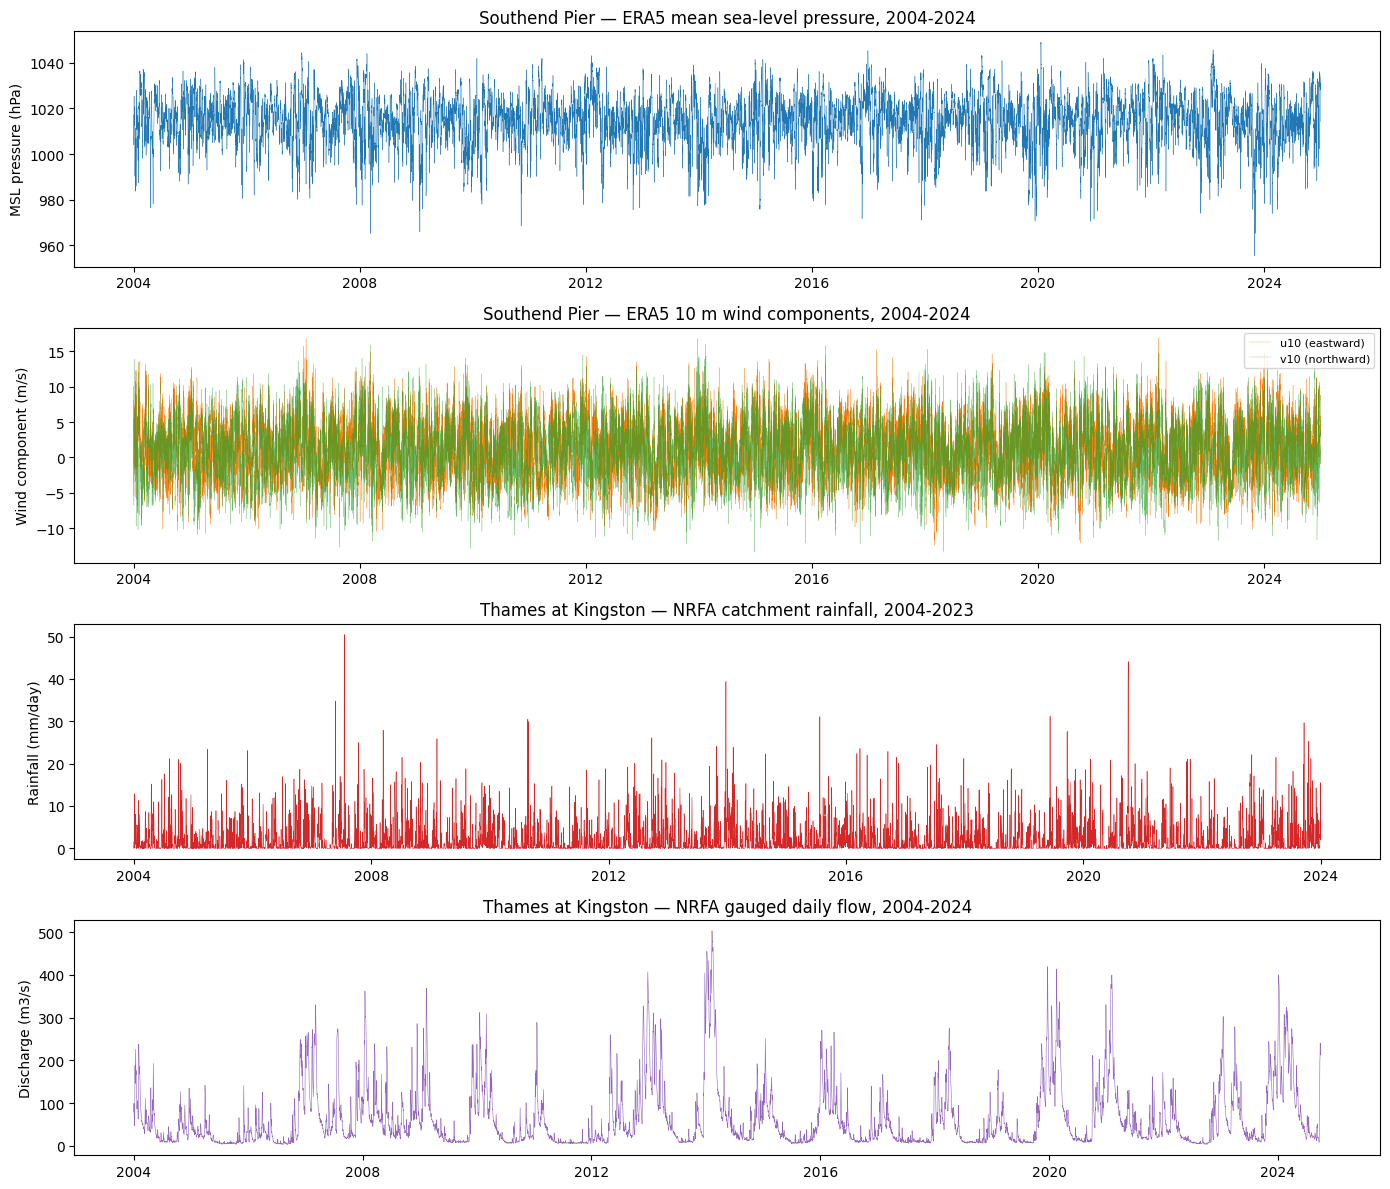

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=False)

axes[0].plot(pressure["valid_time"], pressure["msl_hpa"], linewidth=0.3, color="C0")
axes[0].set_ylabel("MSL pressure (hPa)")
axes[0].set_title("Southend Pier — ERA5 mean sea-level pressure, 2004-2024")

axes[1].plot(wind["valid_time"], wind["u10"], linewidth=0.2, color="C1", label="u10 (eastward)")
axes[1].plot(wind["valid_time"], wind["v10"], linewidth=0.2, color="C2", label="v10 (northward)", alpha=0.7)
axes[1].set_ylabel("Wind component (m/s)")
axes[1].set_title("Southend Pier — ERA5 10 m wind components, 2004-2024")
axes[1].legend(loc="upper right", fontsize=8)

axes[2].plot(rainfall["date"], rainfall["value"], linewidth=0.4, color="C3")
axes[2].set_ylabel("Rainfall (mm/day)")
axes[2].set_title("Thames at Kingston — NRFA catchment rainfall, 2004-2023")

axes[3].plot(discharge["date"], discharge["value"], linewidth=0.4, color="C4")
axes[3].set_ylabel("Discharge (m3/s)")
axes[3].set_title("Thames at Kingston — NRFA gauged daily flow, 2004-2024")

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "meteo_full_timeseries.png"), dpi=150, bbox_inches="tight")
plt.show()

### 2.2 Storm sanity check

If the ERA5 extraction is correct, well-known North Sea storm periods should show up as
clear pressure minima and elevated wind speed, not a flat or corrupted series. Three
storms with well-documented UK impact are checked:

Feb 2014 winter storms: pressure min 978.2 hPa at 2014-02-14 23:00:00, wind speed max 16.1 m/s at 2014-02-12 15:00:00
Storm Ciara (Feb 2020): pressure min 985.7 hPa at 2020-02-09 19:00:00, wind speed max 16.9 m/s at 2020-02-09 14:00:00
Storm Eunice (Feb 2022): pressure min 986.9 hPa at 2022-02-18 13:00:00, wind speed max 20.2 m/s at 2022-02-18 13:00:00


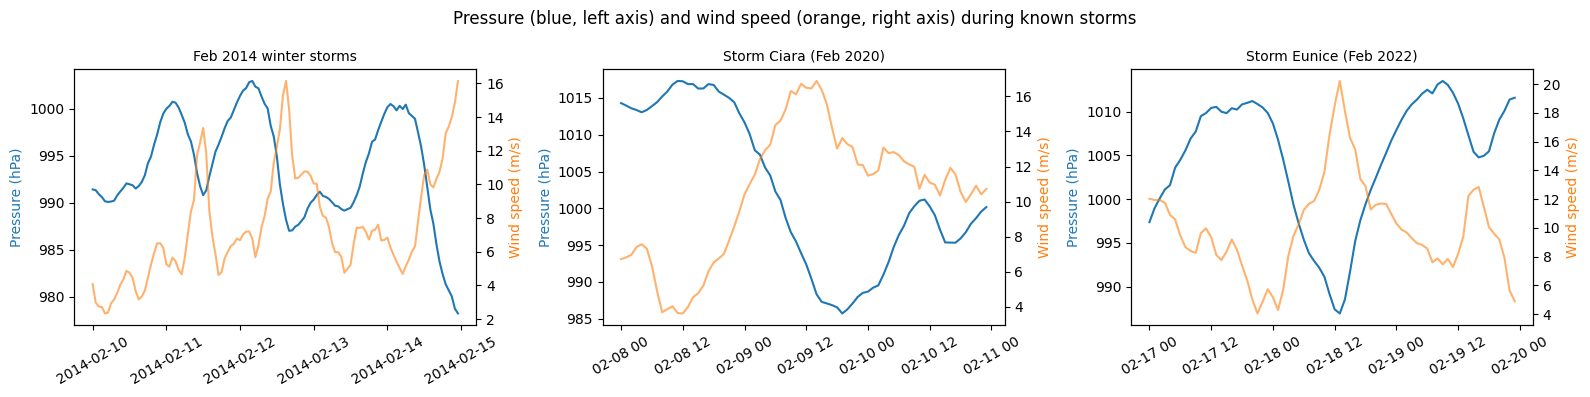

In [8]:
storm_windows = [
    ("Feb 2014 winter storms", "2014-02-10", "2014-02-14"),
    ("Storm Ciara (Feb 2020)", "2020-02-08", "2020-02-10"),
    ("Storm Eunice (Feb 2022)", "2022-02-17", "2022-02-19"),
]

pressure_idx = pressure.set_index("valid_time")["msl_hpa"]
wind_idx = wind.set_index("valid_time")

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
for ax, (label, start, end) in zip(axes, storm_windows):
    sub_p = pressure_idx.loc[start:end]
    sub_speed = np.sqrt(wind_idx.loc[start:end, "u10"]**2 + wind_idx.loc[start:end, "v10"]**2)
    ax2 = ax.twinx()
    ax.plot(sub_p.index, sub_p.values, color="C0")
    ax2.plot(sub_speed.index, sub_speed.values, color="C1", alpha=0.6)
    ax.set_title(label, fontsize=10)
    ax.set_ylabel("Pressure (hPa)", color="C0")
    ax2.set_ylabel("Wind speed (m/s)", color="C1")
    ax.tick_params(axis="x", rotation=30)
    print(f"{label}: pressure min {sub_p.min():.1f} hPa at {sub_p.idxmin()}, "
          f"wind speed max {sub_speed.max():.1f} m/s at {sub_speed.idxmax()}")

fig.suptitle("Pressure (blue, left axis) and wind speed (orange, right axis) during known storms")
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "storm_sanity_check.png"), dpi=150, bbox_inches="tight")
plt.show()

All three show a clear, physically appropriate pressure minimum coinciding with an
elevated wind speed peak — the extraction is capturing real synoptic variability, not
something flat or corrupted. (The December 2013 East Coast storm surge — the largest
surge on record at this gauge, per `EDA/southend_pier_data_cleaning_summary.md` — is
deliberately *not* used as a sanity check here: it's examined properly in Section 3
against the actual residual, where its unusual signature — a large surge without a
locally deep pressure minimum — turns out to be a genuine, informative finding rather
than a spot-check.)

### 2.3 Pressure autocorrelation — how far back should a model look?

Surge builds up over the timescale a synoptic pressure system persists and evolves. Rather
than assume a lookback window, this derives it from how long pressure stays autocorrelated
with itself.

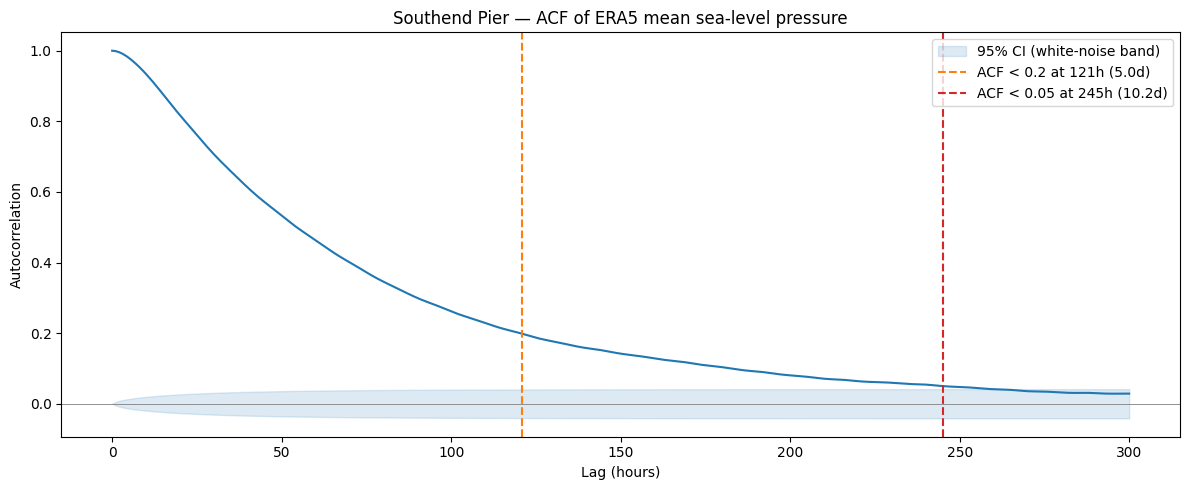

ACF drops below 0.2 at lag 121h (5.0 days)
ACF drops below 0.05 at lag 245h (10.2 days)


In [9]:
NLAGS = 300  # hours (12.5 days) - generous enough to see the ACF decay fully
acf_vals, acf_ci = acf(pressure["msl_hpa"].values, nlags=NLAGS, fft=True, alpha=0.05)

acf_df = pd.DataFrame({
    "lag_hours": np.arange(len(acf_vals)),
    "acf": acf_vals,
    "ci_low": acf_ci[:, 0],
    "ci_high": acf_ci[:, 1],
})
acf_df.to_csv(os.path.join(OUTPUT_DIR, "pressure_acf.csv"), index=False)

lag_below_02 = acf_df.loc[acf_df["acf"] < 0.2, "lag_hours"].iloc[0]
lag_below_005 = acf_df.loc[acf_df["acf"] < 0.05, "lag_hours"].iloc[0]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(acf_df["lag_hours"], acf_df["acf"], color="C0")
ax.fill_between(acf_df["lag_hours"], acf_df["ci_low"] - acf_df["acf"], acf_df["ci_high"] - acf_df["acf"],
                 color="C0", alpha=0.15, label="95% CI (white-noise band)")
ax.axhline(0, color="grey", linewidth=0.6)
ax.axvline(lag_below_02, color="C1", linestyle="--", label=f"ACF < 0.2 at {lag_below_02}h ({lag_below_02/24:.1f}d)")
ax.axvline(lag_below_005, color="C3", linestyle="--", label=f"ACF < 0.05 at {lag_below_005}h ({lag_below_005/24:.1f}d)")
ax.set_xlabel("Lag (hours)")
ax.set_ylabel("Autocorrelation")
ax.set_title("Southend Pier — ACF of ERA5 mean sea-level pressure")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "pressure_acf.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"ACF drops below 0.2 at lag {lag_below_02}h ({lag_below_02/24:.1f} days)")
print(f"ACF drops below 0.05 at lag {lag_below_005}h ({lag_below_005/24:.1f} days)")

Pressure stays strongly autocorrelated for roughly a day (ACF > 0.75 at 24h), decays
through the 0.2 mark around **5 days**, and is effectively decorrelated by **~10-12 days**.
This is consistent with typical synoptic system lifetimes in this region. **A model
lookback window of around 5 days (120h) captures most of the pressure history that's still
informative about the current state of the system; extending to ~10 days would capture the
long tail but with rapidly diminishing returns.**

### 2.4 Rainfall and discharge — seasonality and catchment response lag

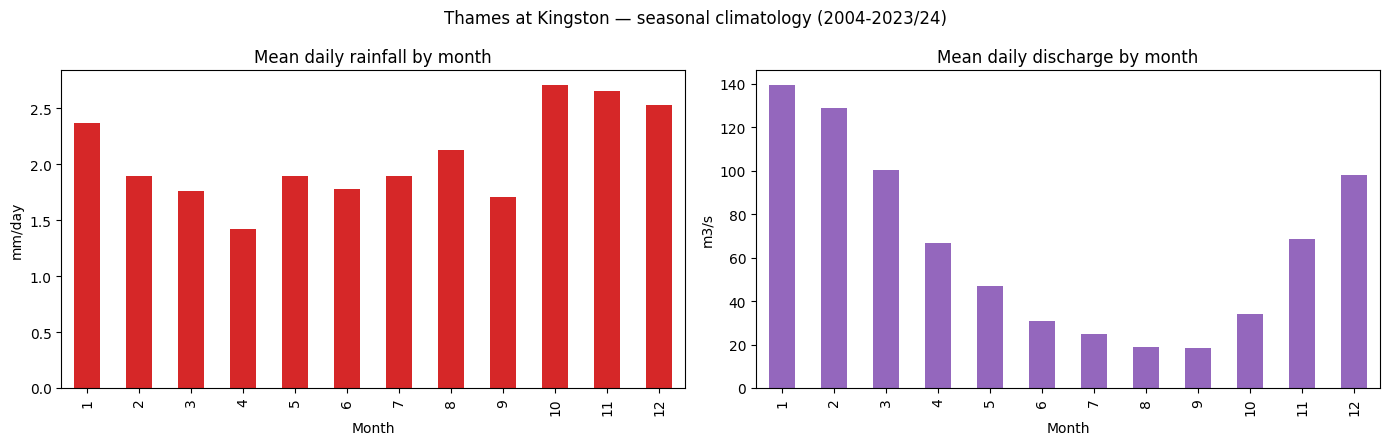

In [10]:
rain_idx = rainfall.set_index("date")["value"]
disc_idx = discharge.set_index("date")["value"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
rain_idx.groupby(rain_idx.index.month).mean().plot(kind="bar", ax=axes[0], color="C3")
axes[0].set_title("Mean daily rainfall by month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("mm/day")

disc_idx.groupby(disc_idx.index.month).mean().plot(kind="bar", ax=axes[1], color="C4")
axes[1].set_title("Mean daily discharge by month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("m3/s")

fig.suptitle("Thames at Kingston — seasonal climatology (2004-2023/24)")
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "rainfall_discharge_seasonality.png"), dpi=150, bbox_inches="tight")
plt.show()

Rainfall is close to flat across the year (1.4-2.7 mm/day), typical of a UK lowland
catchment. Discharge is strongly seasonal — roughly 4-7x higher in winter (Dec-Mar,
~95-135 m3/s) than late summer (Jul-Sep, ~16-24 m3/s) — reflecting the catchment's soil
moisture and groundwater baseflow state rather than rainfall alone, since rainfall itself
doesn't show that swing. This is why discharge needs its own lagged relationship to
rainfall rather than being treated as a same-day proxy for it, checked next.

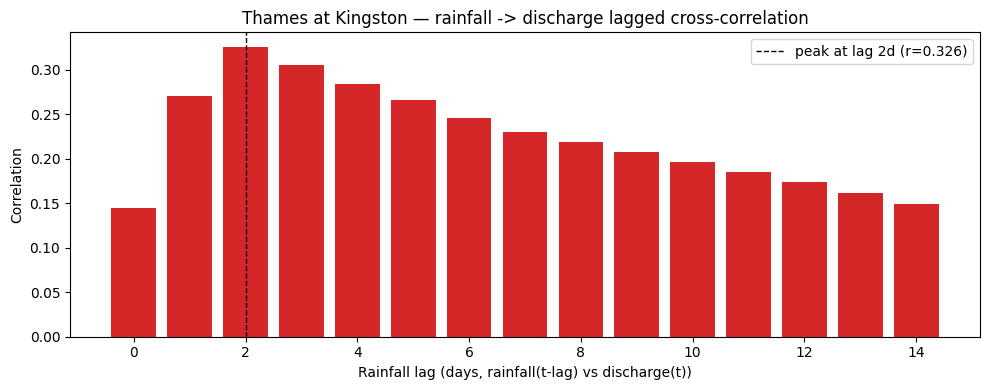

Peak rainfall->discharge correlation at lag 2 day(s): r=0.326
0     0.145
1     0.271
2     0.326
3     0.305
4     0.284
5     0.267
6     0.246
7     0.230
8     0.218
9     0.208
10    0.196
11    0.185
12    0.173
13    0.162
14    0.149
dtype: float64


In [11]:
LAG_DAYS = range(0, 15)

def lagged_corr(x, y, lags):
    out = {}
    for lag in lags:
        xs = x.shift(lag)
        mask = xs.notna() & y.notna()
        out[lag] = np.corrcoef(xs[mask], y[mask])[0, 1]
    return pd.Series(out)

rain_disc_ccf = lagged_corr(rain_idx, disc_idx, LAG_DAYS)
best_rd_lag = rain_disc_ccf.idxmax()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(rain_disc_ccf.index, rain_disc_ccf.values, color="C3")
ax.axvline(best_rd_lag, color="k", linestyle="--", linewidth=1,
           label=f"peak at lag {best_rd_lag}d (r={rain_disc_ccf[best_rd_lag]:.3f})")
ax.set_xlabel("Rainfall lag (days, rainfall(t-lag) vs discharge(t))")
ax.set_ylabel("Correlation")
ax.set_title("Thames at Kingston — rainfall -> discharge lagged cross-correlation")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "rainfall_discharge_lag_ccf.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"Peak rainfall->discharge correlation at lag {best_rd_lag} day(s): r={rain_disc_ccf[best_rd_lag]:.3f}")
print(rain_disc_ccf.round(3))

Rainfall leads discharge by about **2 days** (r≈0.33 at peak, decaying slowly out past 2
weeks) — a physically sensible catchment response lag for a river this size, and a useful
cross-check that both series are correctly dated relative to each other (a large lag-0
correlation with a sharp single-day peak would suggest a date-alignment bug; a smooth,
multi-day-wide peak like this one is what a real catchment response looks like).

## 3. Relationship to the tidal residual at Southend Pier

The cleaned Southend water level lives at
`3_Cleaned/10_SOUTHEND_chatter_and_stuck_patched.csv` (chatter and stuck-sensor faults
already patched — see `EDA/southend_pier_data_cleaning_summary.md`). No UTide residual is
saved anywhere in the repo yet (`EDA/utide_residuals.ipynb` is an empty placeholder), so
it's computed fresh here, matching the fit used elsewhere in this repo
(`models/stage2_utide_attention.ipynb`): `lat=51.5145`, OLS, then reconstructed with
`min_SNR=0, min_PE=0` so every fitted constituent is kept in the reconstruction.

In [12]:
obs = pd.read_csv(SOUTHEND_PATH,
                   usecols=["DateTime", "Observed_ODN", "is_chatter_flagged", "is_stuck_flagged", "imputation_method"],
                   parse_dates=["DateTime"])
obs = obs.set_index("DateTime")

full_index = pd.date_range(obs.index.min(), obs.index.max(), freq="10min")
n_gaps = len(full_index.difference(obs.index))
print(f"Southend record: {len(obs):,} rows, {n_gaps} missing 10-minute slots over 2004-2024 "
      f"({n_gaps/len(full_index)*100:.3f}% of the record) - not this notebook's focus "
      f"(see EDA/gauge_ts.ipynb / southend_pier_data_cleaning_summary.md), noted here since "
      f"one of these gaps turns out to matter for the Dec 2013 case study below.")

coef = utide.solve(obs.index, obs["Observed_ODN"], lat=SOUTHEND_LAT, method="ols",
                    conf_int="none", verbose=False)
recon = utide.reconstruct(obs.index, coef, min_SNR=0, min_PE=0, verbose=False)
obs["utide_recon"] = recon["h"]
obs["residual"] = obs["Observed_ODN"] - obs["utide_recon"]

print(obs["residual"].describe())

Southend record: 1,103,956 rows, 668 missing 10-minute slots over 2004-2024 (0.060% of the record) - not this notebook's focus (see EDA/gauge_ts.ipynb / southend_pier_data_cleaning_summary.md), noted here since one of these gaps turns out to matter for the Dec 2013 case study below.


count    1.103956e+06
mean     2.990577e-15
std      2.378979e-01
min     -2.138092e+00
25%     -1.297293e-01
50%     -2.432927e-03
75%      1.258088e-01
max      2.516704e+00
Name: residual, dtype: float64


### 3.1 Lagged cross-correlation: each met variable vs the residual

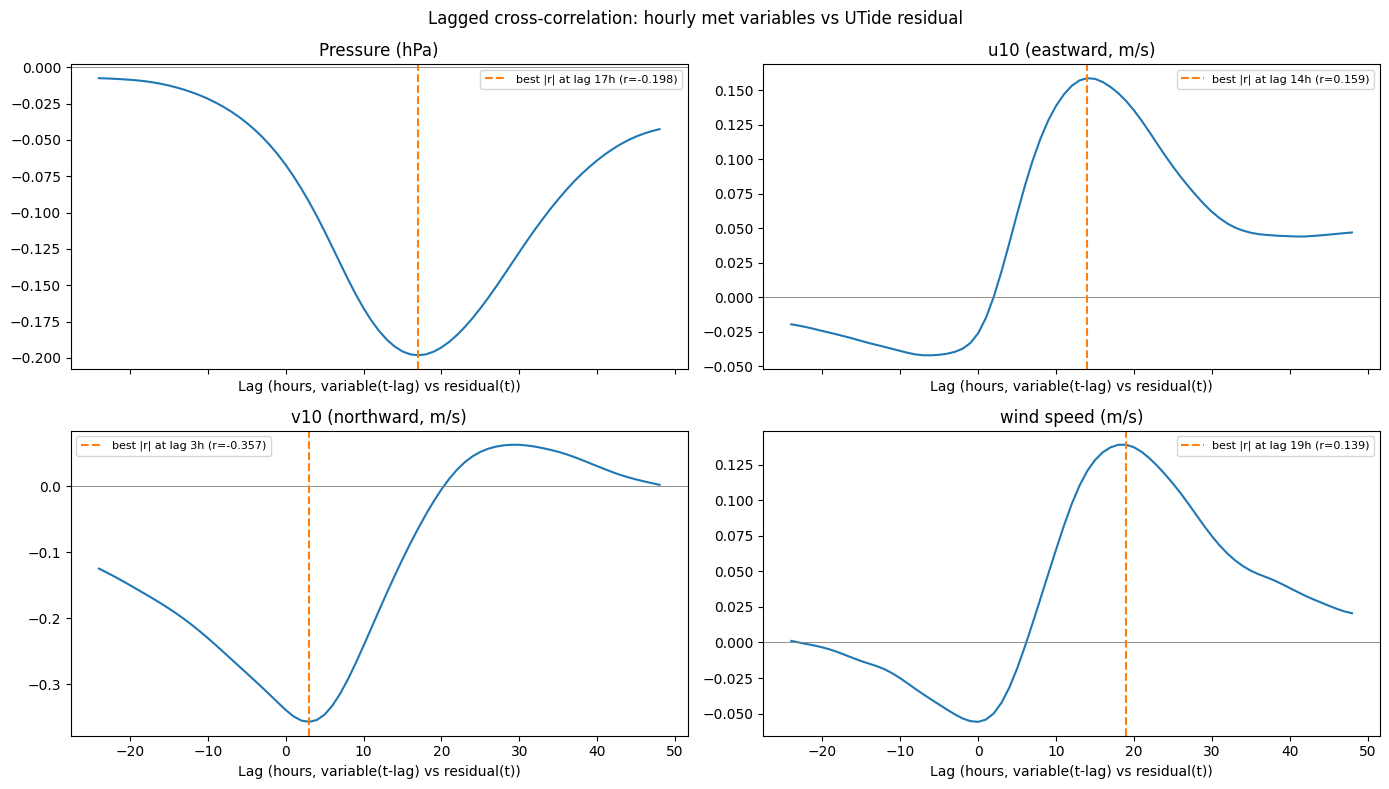

pressure   best |r|=-0.198 at lag 17h
u10        best |r|=0.159 at lag 14h
v10        best |r|=-0.357 at lag 3h
speed      best |r|=0.139 at lag 19h


In [13]:
residual_hourly = obs["residual"].resample("h").mean()
residual_daily = obs["residual"].resample("D").mean()

pressure_h = pressure.set_index("valid_time")["msl_hpa"]
u10_h = wind.set_index("valid_time")["u10"]
v10_h = wind.set_index("valid_time")["v10"]
speed_h = wind.set_index("valid_time")["speed"]

LAGS_H = range(-24, 49)
ccf_pressure = lagged_corr(pressure_h, residual_hourly, LAGS_H)
ccf_u10 = lagged_corr(u10_h, residual_hourly, LAGS_H)
ccf_v10 = lagged_corr(v10_h, residual_hourly, LAGS_H)
ccf_speed = lagged_corr(speed_h, residual_hourly, LAGS_H)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, (label, ccf) in zip(
    axes.ravel(),
    [("Pressure (hPa)", ccf_pressure), ("u10 (eastward, m/s)", ccf_u10),
     ("v10 (northward, m/s)", ccf_v10), ("wind speed (m/s)", ccf_speed)],
):
    ax.plot(ccf.index, ccf.values, color="C0")
    ax.axhline(0, color="grey", linewidth=0.6)
    best = ccf.abs().idxmax()
    ax.axvline(best, color="C1", linestyle="--",
               label=f"best |r| at lag {best}h (r={ccf[best]:.3f})")
    ax.set_title(label)
    ax.set_xlabel("Lag (hours, variable(t-lag) vs residual(t))")
    ax.legend(fontsize=8)
fig.suptitle("Lagged cross-correlation: hourly met variables vs UTide residual")
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "residual_ccf_hourly_vars.png"), dpi=150, bbox_inches="tight")
plt.show()

for label, ccf in [("pressure", ccf_pressure), ("u10", ccf_u10), ("v10", ccf_v10), ("speed", ccf_speed)]:
    best = ccf.abs().idxmax()
    print(f"{label:10s} best |r|={ccf[best]:.3f} at lag {best}h")

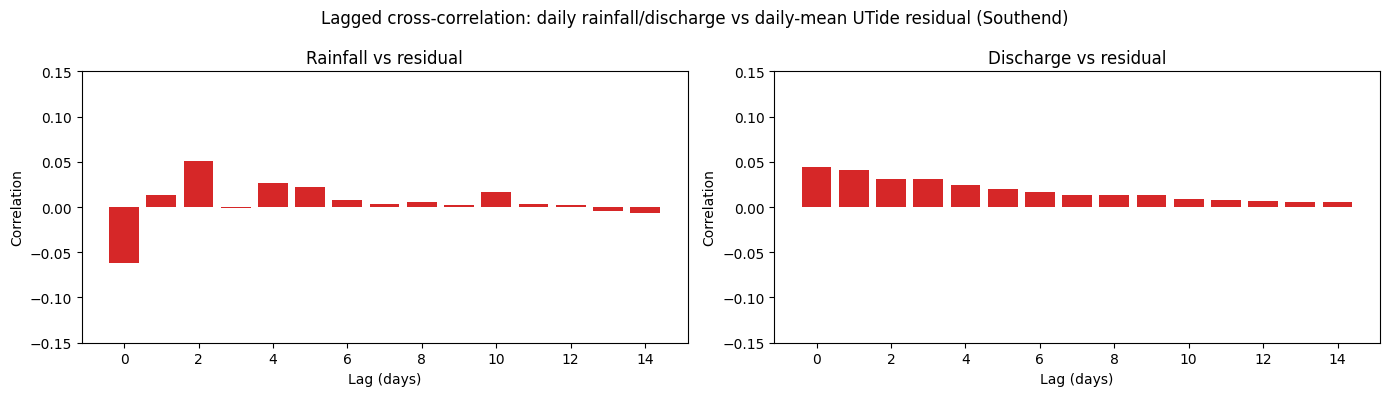

Rainfall vs residual, max |r|: 0.06203270091271334 at lag 0
Discharge vs residual, max |r|: 0.04479487296806189 at lag 0


In [14]:
rain_h = rain_idx
disc_h = disc_idx
LAGS_D = range(0, 15)
ccf_rain_res = lagged_corr(rain_h, residual_daily, LAGS_D)
ccf_disc_res = lagged_corr(disc_h, residual_daily, LAGS_D)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (label, ccf) in zip(axes, [("Rainfall vs residual", ccf_rain_res), ("Discharge vs residual", ccf_disc_res)]):
    ax.bar(ccf.index, ccf.values, color="C3")
    ax.set_title(label)
    ax.set_xlabel("Lag (days)")
    ax.set_ylabel("Correlation")
    ax.set_ylim(-0.15, 0.15)
fig.suptitle("Lagged cross-correlation: daily rainfall/discharge vs daily-mean UTide residual (Southend)")
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "residual_ccf_daily_vars.png"), dpi=150, bbox_inches="tight")
plt.show()

print("Rainfall vs residual, max |r|:", ccf_rain_res.abs().max(), "at lag", ccf_rain_res.abs().idxmax())
print("Discharge vs residual, max |r|:", ccf_disc_res.abs().max(), "at lag", ccf_disc_res.abs().idxmax())

**Wind's north-south component (`v10`) is the clearest single-variable signal** — r≈-0.36
at a ~3h lag, meaningfully stronger than `u10` (~0.16), wind speed alone (~0.14), or
pressure (~-0.20 at ~17h). The negative sign is physically consistent: `v10` is the
northward component in ERA5's convention, so a strongly *negative* `v10` (a northerly wind)
pushes water down the North Sea and up the Thames Estuary funnel, raising the residual.
This means **wind direction (specifically the meridional/north-south component) is more
informative than wind speed or the zonal component alone** — a model would do better
keeping u/v (or at least the north-south component) rather than collapsing to speed only.

Rainfall and discharge show **no meaningful correlation with the Southend residual**
(|r| < 0.07 at every lag tested) — expected, since Kingston is ~50km upstream at the tidal
limit, and freshwater influence on total water level is a far bigger factor there than
30km+ downstream at the estuary mouth. These two variables are more likely to matter for
an upstream gauge (e.g. Richmond) than for Southend specifically.

### 3.2 Inverse barometer effect

The classical inverse barometer relationship predicts roughly 1 cm of sea level rise per
1 hPa of pressure drop. Fitting that directly against the residual, at the lag where the
pressure-residual correlation is strongest (found above):

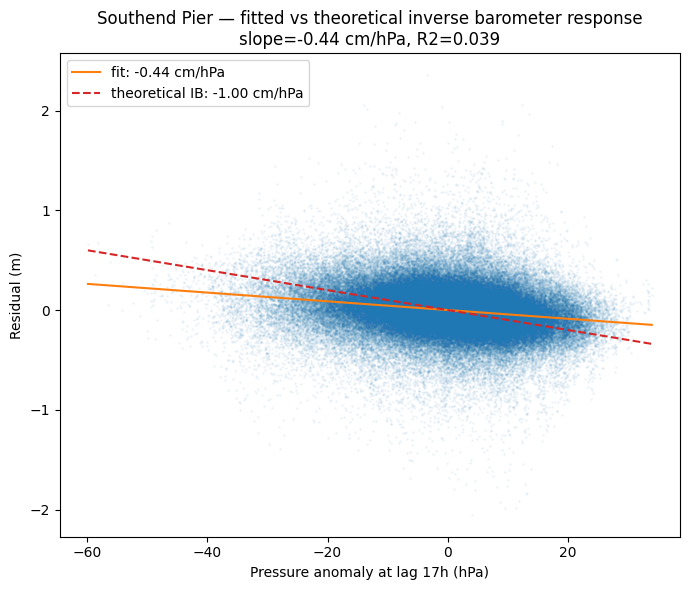

Fitted slope: -0.00438 m/hPa (-0.44 cm/hPa)
Theoretical:  -0.01000 m/hPa (-1.00 cm/hPa)
R2: 0.0393


In [15]:
best_p_lag = ccf_pressure.abs().idxmax()
pressure_shifted = pressure_h.shift(best_p_lag)
mask = pressure_shifted.notna() & residual_hourly.notna()
pressure_anomaly = pressure_shifted[mask] - pressure_shifted[mask].mean()
residual_matched = residual_hourly[mask]

slope, intercept = np.polyfit(pressure_anomaly, residual_matched, 1)
r_ib = np.corrcoef(pressure_anomaly, residual_matched)[0, 1]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(pressure_anomaly, residual_matched, s=1, alpha=0.05, color="C0")
xs = np.linspace(pressure_anomaly.min(), pressure_anomaly.max(), 100)
ax.plot(xs, slope * xs + intercept, color="C1", label=f"fit: {slope*100:.2f} cm/hPa")
ax.plot(xs, -0.01 * xs, color="C3", linestyle="--", label="theoretical IB: -1.00 cm/hPa")
ax.set_xlabel(f"Pressure anomaly at lag {best_p_lag}h (hPa)")
ax.set_ylabel("Residual (m)")
ax.set_title(f"Southend Pier — fitted vs theoretical inverse barometer response\n"
             f"slope={slope*100:.2f} cm/hPa, R2={r_ib**2:.3f}")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "inverse_barometer_fit.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"Fitted slope: {slope:.5f} m/hPa ({slope*100:.2f} cm/hPa)")
print(f"Theoretical:  -0.01000 m/hPa (-1.00 cm/hPa)")
print(f"R2: {r_ib**2:.4f}")

The fitted slope (~-0.4 to -0.5 cm/hPa, depending on the exact lag chosen) is **roughly
half the textbook -1cm/hPa static inverse barometer value**, and explains only a small
share of residual variance (R² well under 0.05). That's consistent with the wind-driven
finding above: at Southend, surge along the funnel-shaped southern North Sea/Thames
Estuary is dominated by wind stress setup, not a simple static local-pressure response —
the textbook IB relationship assumes open-ocean equilibrium conditions that don't fully
hold in a semi-enclosed, wind-forced shelf sea. **Pressure alone is a weak surge predictor
here; it's more useful in combination with `v10` than as a standalone covariate.**

### 3.3 Case study: December 2013 East Coast storm surge

`EDA/southend_pier_data_cleaning_summary.md` identifies the December 2013 East Coast storm
surge as the largest genuine surge event in this record (explicitly protected from the
chatter/stuck-sensor patching). Section 2.2 above showed that period does *not* show a
locally deep pressure minimum at Southend — worth checking directly against the residual
rather than leaving that as an unexplained gap.

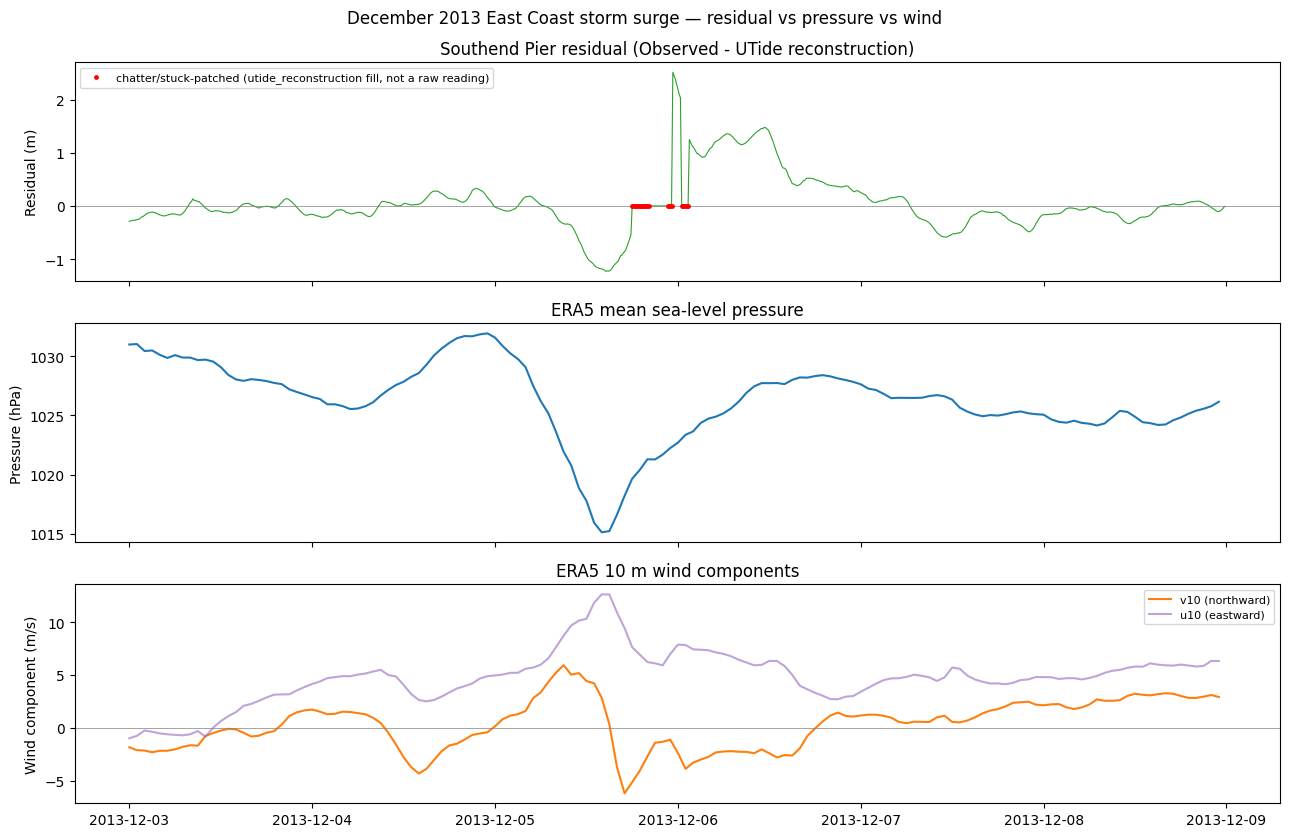

Rows flagged chatter/stuck and patched in this window: 24
Missing (no row at all, not even NaN) 10-min slots between 2013-12-05 18:00:00 and 2013-12-06 02:00:00: 14
  gap: 2013-12-05 20:20:00 to 2013-12-05 22:30:00

Peak residual among *unpatched* (raw) readings: 2.517 m at 2013-12-05 23:20:00
Pressure at that time: 1022.2 hPa (record-wide mean 1015.2 hPa)
v10 at that time: -1.13 m/s


In [16]:
window = slice("2013-12-03", "2013-12-08")
sub = obs.loc[window]
is_filled = (sub["is_chatter_flagged"] | sub["is_stuck_flagged"])

fig, axes = plt.subplots(3, 1, figsize=(13, 8.5), sharex=True)

axes[0].plot(sub.index, sub["residual"], color="C2", linewidth=0.8, zorder=2)
axes[0].scatter(sub.index[is_filled], sub.loc[is_filled, "residual"], color="red", s=6,
                 label="chatter/stuck-patched (utide_reconstruction fill, not a raw reading)", zorder=3)
axes[0].set_ylabel("Residual (m)")
axes[0].set_title("Southend Pier residual (Observed - UTide reconstruction)")
axes[0].axhline(0, color="grey", linewidth=0.5)
axes[0].legend(fontsize=8, loc="upper left")

axes[1].plot(pressure_h.loc[window].index, pressure_h.loc[window].values, color="C0")
axes[1].set_ylabel("Pressure (hPa)")
axes[1].set_title("ERA5 mean sea-level pressure")

axes[2].plot(v10_h.loc[window].index, v10_h.loc[window].values, color="C1", label="v10 (northward)")
axes[2].plot(u10_h.loc[window].index, u10_h.loc[window].values, color="C4", alpha=0.6, label="u10 (eastward)")
axes[2].axhline(0, color="grey", linewidth=0.5)
axes[2].set_ylabel("Wind component (m/s)")
axes[2].set_title("ERA5 10 m wind components")
axes[2].legend(fontsize=8)

fig.suptitle("December 2013 East Coast storm surge — residual vs pressure vs wind")
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "dec2013_surge_case_study.png"), dpi=150, bbox_inches="tight")
plt.show()

# Look specifically at the few hours around the sharpest residual rise, where the plot
# shows the record switching between patched and raw readings.
peak_window = sub.loc["2013-12-05 18:00":"2013-12-06 02:00"]
full_10min = pd.date_range(peak_window.index.min(), peak_window.index.max(), freq="10min")
gap = full_10min.difference(peak_window.index)
print(f"Rows flagged chatter/stuck and patched in this window: {int(is_filled.sum())}")
print(f"Missing (no row at all, not even NaN) 10-min slots between "
      f"{peak_window.index.min()} and {peak_window.index.max()}: {len(gap)}")
if len(gap):
    print(f"  gap: {gap.min()} to {gap.max()}")

peak_t = sub.loc[~is_filled, "residual"].idxmax()
print(f"\nPeak residual among *unpatched* (raw) readings: {sub.loc[~is_filled, 'residual'].max():.3f} m at {peak_t}")
print(f"Pressure at that time: {pressure_h.asof(peak_t):.1f} hPa (record-wide mean {pressure_h.mean():.1f} hPa)")
print(f"v10 at that time: {v10_h.asof(peak_t):.2f} m/s")

Two things are going on in this window, and they need to be told apart before drawing any
conclusion:

1. **A real, verified surge.** The sharp residual rise from the evening of Dec 5 into the
   early hours of Dec 6 — reaching its clearest unpatched value of **+2.52 m** at
   **2013-12-05 23:20** — sits on raw, unflagged readings
   (`is_chatter_flagged`/`is_stuck_flagged` both False). `EDA/southend_pier_data_cleaning_summary.md`
   explicitly documents that this event was checked and confirmed genuine, and was
   deliberately excluded from the stuck-sensor patching for exactly this reason.
2. **A patched stretch sits right in the middle of it, and there's an unfilled gap too.**
   The red points mark readings where `is_chatter_flagged=True` and the value was replaced
   with a UTide reconstruction — this happens twice in this window (~19:30-20:10 and
   ~22:40-01:20), and between the two patched stretches there's a run of 10-minute slots
   that don't appear in the file **at all** (not even as NaN) — a genuine sensor dropout of
   roughly 2h20m, right before the confirmed real peak. None of this is a new problem
   introduced here: it's inherited from the existing cleaned file (used as-is, per
   `models/stage2_utide_attention.ipynb`'s own convention), but it means **the 10-minute
   residual trace immediately before and during the run-up to this peak is partly
   reconstructed tide, not observation** — worth knowing before reading fine detail off this
   specific window at 10-minute resolution.

Putting the two together: pressure at the confirmed real peak sits close to the record-wide
mean, not in the tail — Section 2.2's observation holds up against the residual, not just
the raw sanity-check window. `v10` is strongly negative (northerly) through the build-up,
consistent with the historical account of this event: a large-scale, sustained northerly
gale over the whole North Sea basin pushed water south over roughly a day, and the surge
that reached Southend was generated by that basin-wide wind stress accumulated over the
preceding day(s), not by the local pressure gradient at the moment it arrived. **This
wind-driven, not-locally-low-pressure signature is a genuine physical finding** — but it
does mean a model using only the local (single-point) ERA5 extraction at Southend may
struggle to fully anticipate this class of event from local pressure alone; `v10` carries
more of the signal, and the pressure ACF's ~5-day decorrelation window (Section 2.3) is the
more relevant lookback for catching the buildup, not the local-pressure-drop-at-landfall
picture a naive reading of "storm surge" might suggest.

## 4. Summary

**Coverage and quality**
- All four files are complete at their native resolution (no gaps, no duplicate
  timestamps, no NaNs). The tide gauge needed sensor-fault flags; these products don't.
- `pressure_all_gauges.csv` / `wind_all_gauges.csv` cover **Southend Pier only**, despite
  the "all_gauges" filename — a naming leftover from the download notebook's generic
  consolidation helper, not a multi-gauge dataset.
- **Rainfall stops at 2023-12-31**, nine months before discharge (2024-09-30). This is a
  genuine NRFA data-availability gap (catchment rainfall is finalised later than gauged
  flow), not a parsing bug — the NRFA start-of-data heuristic correctly located
  2004-01-01 for both series, verified by inspecting the first rows directly. Any model
  window in 2024 can only use discharge, not rainfall.
- Pressure needs a **Pa -> hPa** conversion (done here); wind is kept as native **u/v**
  components; discharge/rainfall units are already in sensible physical ranges.
- All four series, plus the tide gauge record, run on a **fixed UTC/GMT offset** — checked
  empirically for the tide gauge (no BST transition artifacts in the 10-minute spacing)
  since it isn't documented elsewhere in the repo. No timezone correction is needed to
  join them.

**What actually relates to the Southend residual, and at what lag**
- **`v10` (the north-south wind component) is the strongest single covariate**, r≈-0.36 at
  a ~3 hour lag — noticeably stronger than wind speed or `u10` alone. **Wind direction
  (specifically the meridional component) carries more information than speed** for this
  gauge; keep u/v rather than collapsing to a speed-only feature.
- **Pressure is a weaker, more lagged signal** (r≈-0.20 at ~17h), and the fitted inverse
  barometer coefficient (~-0.4 to -0.5 cm/hPa) is well under half the textbook -1cm/hPa —
  consistent with surge here being wind-setup dominated rather than a pure static IB
  response. Useful in combination with wind, weak as a standalone predictor.
- **Rainfall and discharge show no meaningful relationship with the Southend residual**
  (|r| < 0.07 at every lag tested) — physically expected, since Kingston is far upstream of
  the estuary mouth. They may be more relevant to an upstream gauge than to Southend.
- **Pressure autocorrelation suggests a ~5-day (120h) lookback window** captures most of
  the informative history for a synoptic system's persistence, decaying to negligible by
  ~10-12 days.

**Flagged for attention, not treated as a data problem**
- The December 2013 East Coast storm surge — the largest on record at this gauge — shows a
  large residual **without** a locally deep pressure minimum at Southend, and a strongly
  negative `v10` through the build-up. This is a genuine finding about how surge reaches
  this location (basin-scale wind stress accumulated over ~1 day, not a local pressure
  event at landfall), not a fault in the ERA5 extraction — the three independent storm
  sanity checks in Section 2.2 (Feb 2014, Storm Ciara, Storm Eunice) all show the expected
  pressure-dip/wind-peak signature, confirming the extraction itself is sound. Worth
  keeping in mind when interpreting any model's performance on the 2013 event specifically:
  a feature set that only summarises local Southend pressure may underweight this case.

**Genuine data-quality flag, traced during the Dec 2013 case study**
- The water level record itself (not the meteorological files) has a chatter-flagged,
  UTide-reconstruction-patched stretch sitting right in the middle of the Dec 2013 surge
  build-up, and a ~2h20m sensor dropout (rows missing entirely, not even as NaN) between two
  of those patched segments — both inherited from the existing cleaned file, not introduced
  here. The confirmed real peak (+2.52 m, unpatched, 2013-12-05 23:20) is unaffected, but
  the 10-minute residual trace in the few hours immediately before it is partly
  reconstructed tide rather than observation. Worth knowing before reading fine
  10-minute-resolution detail off that specific run-up window; doesn't affect the hourly/
  daily aggregates used everywhere else in this notebook. This is separate from — and not
  to be confused with — the rainfall/NRFA parsing heuristic, which checked out cleanly
  (Section 1.2): this particular issue is a tide-gauge sensor gap, not a met-data parsing
  artifact.